In [21]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34019 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34019/status,
Dashboard: http://127.0.0.1:34019/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45149,Workers: 0
Dashboard: http://127.0.0.1:34019/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44415,Total threads: 8
Dashboard: http://127.0.0.1:34327/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:43065,


### Load MITgcm Output from Assimilations

In [22]:
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/TPOSE_TAO/OSM_2026/'

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [24]:
from xmitgcm import open_mdsdataset

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+31+28 # nov, dec, jan, feb (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

### Load TAO U and V

In [25]:
lon_str = '140'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_140 = xr.open_dataset(TAO_ADCP_file)

lon_str = '110'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_110 = xr.open_dataset(TAO_ADCP_file)

lon_str = '170'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_170 = xr.open_dataset(TAO_ADCP_file)

dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])

/tmp/ipykernel_2343913/2979973856.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_2343913/2979973856.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_2343913/2979973856.py:13: FutureWarning: In a future version of xarra

In [26]:
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-03-01')) # subset to sep 2012, mar 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

In [27]:
dsTAO

<xarray.Dataset> Size: 543kB
Dimensions:  (time: 182, depth: 62, lat: 1, lon: 3)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2012-09-01T12:00:00 ... 2013-03-01T12:...
  * depth    (depth) float32 248B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 12B 190.0 220.0 250.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 135kB nan nan nan ... nan nan nan
    QU_5205  (time, depth, lat, lon) float32 135kB 0.0 0.0 0.0 ... 0.0 nan 0.0
    v_1206   (time, depth, lat, lon) float32 135kB nan nan nan ... nan nan nan
    QV_5206  (time, depth, lat, lon) float32 135kB 0.0 0.0 0.0 ... 0.0 nan 0.0
Attributes:
    platform_code:                0n110w
    site_code:                    0n110w
    wmo_platform_code:            32323
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                09:59 14-AUG-2024

In [28]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()

# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


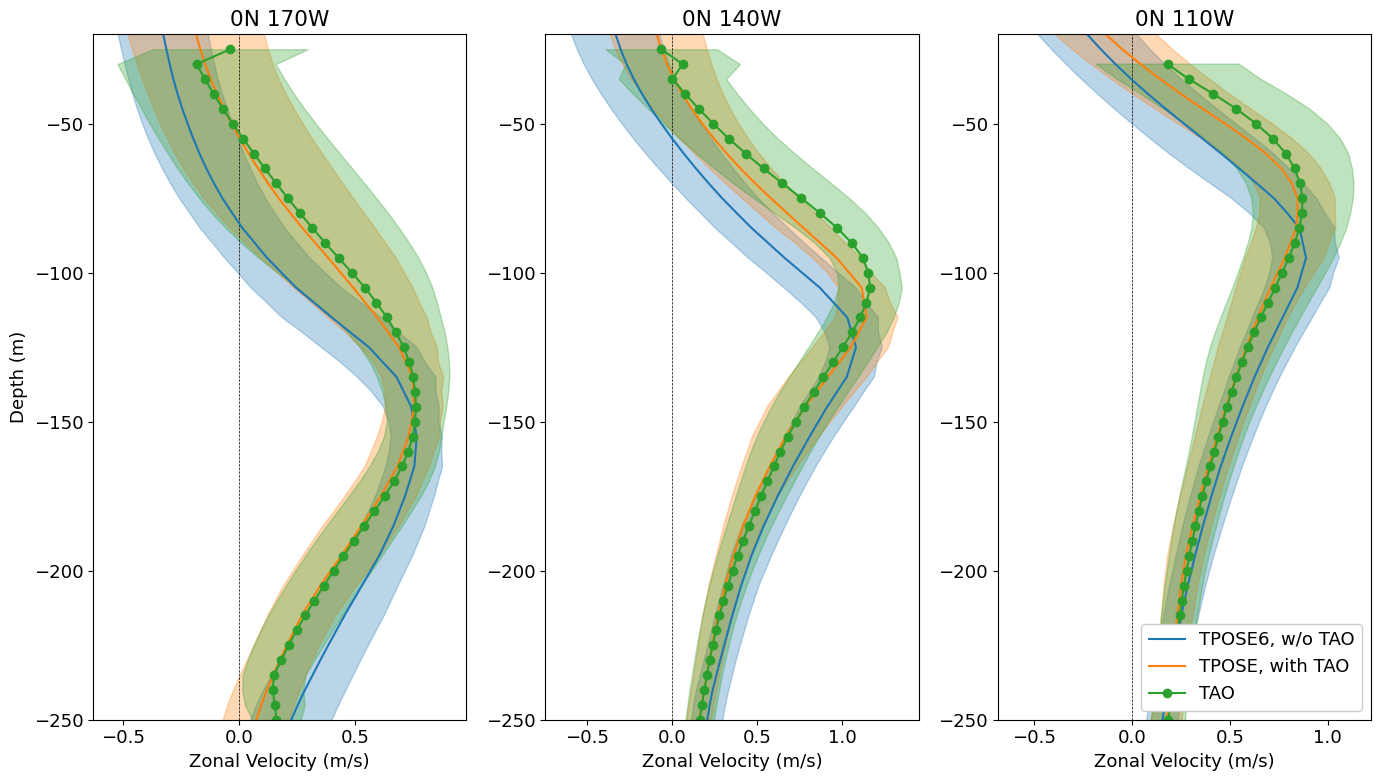

In [44]:
fig,ax = plt.subplots(figsize=(14,8),ncols=3)
ax[0].axvline(0,color='k',linewidth=0.5,label='_nolabel_',linestyle='--')
ax[1].axvline(0,color='k',linewidth=0.5,label='_nolabel_',linestyle='--')
ax[2].axvline(0,color='k',linewidth=0.5,label='_nolabel_',linestyle='--')

U_noTAO = tpose_U_noTAO.sel(XG=190.0)
U_withTAO = tpose_U_TAO.sel(XG=190.0)

U_noTAO.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE6, w/o TAO')
ax[0].fill_betweenx(U_noTAO.Z,U_noTAO.mean(dim='time')-U_noTAO.std(dim='time'),U_noTAO.mean(dim='time')+U_noTAO.std(dim='time'),color='C0',alpha=0.3)
U_withTAO.mean(dim='time').plot(ax=ax[0],y='Z',label='TPOSE, with TAO')
ax[0].fill_betweenx(U_withTAO.Z,U_withTAO.mean(dim='time')-U_withTAO.std(dim='time'),U_withTAO.mean(dim='time')+U_withTAO.std(dim='time'),color='C1',alpha=0.3)
TAO_mean = dsTAO.u_1205.sel(XC=190).mean(dim='time').squeeze()
TAO_std = dsTAO.u_1205.sel(XC=190).std(dim='time').squeeze()
TAO_mean.plot(ax=ax[0],y='Z',label='TAO',marker='o',color='tab:green')
ax[0].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='tab:green',alpha=0.3)
ax[0].set_title('0N 170W')
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Zonal Velocity (m/s)')
ax[0].set_ylim(-250,-20)

U_noTAO = tpose_U_noTAO.sel(XG=220.0)
U_withTAO = tpose_U_TAO.sel(XG=220.0)

U_noTAO.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE6, w/o TAO')
ax[1].fill_betweenx(U_noTAO.Z,U_noTAO.mean(dim='time')-U_noTAO.std(dim='time'),U_noTAO.mean(dim='time')+U_noTAO.std(dim='time'),color='C0',alpha=0.3)
U_withTAO.mean(dim='time').plot(ax=ax[1],y='Z',label='TPOSE, with TAO')
ax[1].fill_betweenx(U_withTAO.Z,U_withTAO.mean(dim='time')-U_withTAO.std(dim='time'),U_withTAO.mean(dim='time')+U_withTAO.std(dim='time'),color='C1',alpha=0.3)
TAO_mean = dsTAO.u_1205.sel(XC=220).mean(dim='time').squeeze()
TAO_std = dsTAO.u_1205.sel(XC=220).std(dim='time').squeeze()
TAO_mean.plot(ax=ax[1],y='Z',label='TAO',marker='o')
ax[1].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C2',alpha=0.3)
ax[1].set_title('0N 140W')
ax[1].set_ylabel('')
ax[1].set_xlabel('Zonal Velocity (m/s)')
ax[1].set_ylim(-250,-20)

U_noTAO = tpose_U_noTAO.sel(XG=250.0)
U_withTAO = tpose_U_TAO.sel(XG=250.0)

U_noTAO.mean(dim='time').plot(ax=ax[2],y='Z',label='TPOSE6, w/o TAO')
ax[2].fill_betweenx(U_noTAO.Z,U_noTAO.mean(dim='time')-U_noTAO.std(dim='time'),U_noTAO.mean(dim='time')+U_noTAO.std(dim='time'),color='C0',alpha=0.3)
U_withTAO.mean(dim='time').plot(ax=ax[2],y='Z',label='TPOSE, with TAO')
ax[2].fill_betweenx(U_withTAO.Z,U_withTAO.mean(dim='time')-U_withTAO.std(dim='time'),U_withTAO.mean(dim='time')+U_withTAO.std(dim='time'),color='C1',alpha=0.3)
TAO_mean = dsTAO.u_1205.sel(XC=250).mean(dim='time').squeeze()
TAO_std = dsTAO.u_1205.sel(XC=250).std(dim='time').squeeze()
TAO_mean.plot(ax=ax[2],y='Z',label='TAO',marker='o')
ax[2].fill_betweenx(dsTAO.Z,TAO_mean-TAO_std,TAO_mean+TAO_std,color='C2',alpha=0.3)
ax[2].set_title('0N 110W')
ax[2].set_ylabel('')
ax[2].set_xlabel('Zonal Velocity (m/s)')
ax[2].legend(loc='lower right',framealpha=1)
ax[2].set_ylim(-250,-20)

plt.tight_layout()
fig.savefig(foldername+'UV_mean_prof.png')

In [45]:
def vertical_shear(U):
    # dU/dz on Z grid (units: s^-1)
    return U.differentiate('Z')

/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/edavenport/miniforge3/envs/tpose/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: De

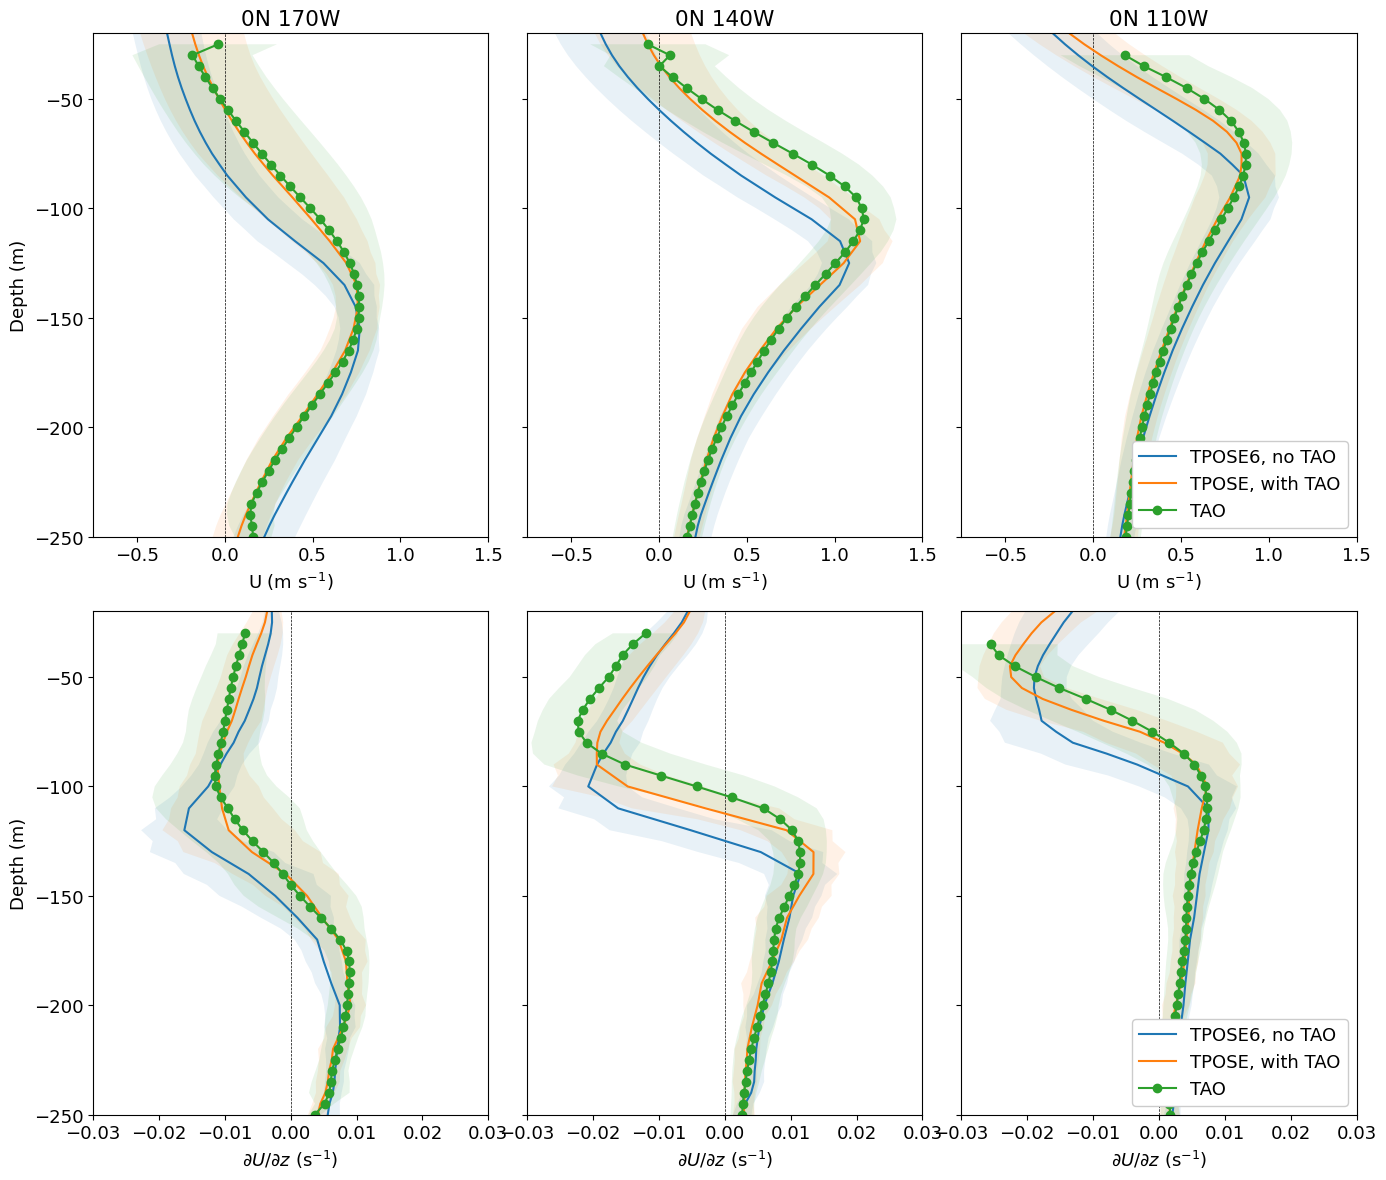

In [55]:
fig, ax = plt.subplots(
    figsize=(14, 12),
    nrows=2,
    ncols=3,
    sharey=True
)

XGs = [190.0, 220.0, 250.0]
titles = ['0N 170W', '0N 140W', '0N 110W']

for i, (xg, title) in enumerate(zip(XGs, titles)):

    # ------------------
    # Velocity (row 0)
    # ------------------
    ax[0, i].axvline(0, color='k', lw=0.5, ls='--')

    U_noTAO = tpose_U_noTAO.sel(XG=xg)
    U_withTAO = tpose_U_TAO.sel(XG=xg)

    U_noTAO.mean('time').plot(ax=ax[0, i], y='Z', label='TPOSE6, no TAO')
    ax[0, i].fill_betweenx(
        U_noTAO.Z,
        U_noTAO.mean('time') - U_noTAO.std('time'),
        U_noTAO.mean('time') + U_noTAO.std('time'),
        alpha=0.1
    )

    U_withTAO.mean('time').plot(ax=ax[0, i], y='Z', label='TPOSE, with TAO')
    ax[0, i].fill_betweenx(
        U_withTAO.Z,
        U_withTAO.mean('time') - U_withTAO.std('time'),
        U_withTAO.mean('time') + U_withTAO.std('time'),
        alpha=0.1
    )

    TAO_mean = dsTAO.u_1205.sel(XC=xg).mean('time').squeeze()
    TAO_std  = dsTAO.u_1205.sel(XC=xg).std('time').squeeze()

    TAO_mean.plot(ax=ax[0, i], y='Z', marker='o', label='TAO')
    ax[0, i].fill_betweenx(
        dsTAO.Z, TAO_mean - TAO_std, TAO_mean + TAO_std,
        alpha=0.1
    )

    ax[0, i].set_title(title)
    ax[0, i].set_ylim(-250, -20)
    ax[0, i].set_xlim(-0.75, 1.5)
    ax[0, i].set_xlabel('U (m s$^{-1}$)')
    ax[0, i].set_ylabel('')

    # ------------------
    # Shear (row 1)
    # ------------------
    ax[1, i].axvline(0, color='k', lw=0.5, ls='--')

    dUdz_noTAO   = vertical_shear(U_noTAO)
    dUdz_withTAO = vertical_shear(U_withTAO)
    dUdz_TAO     = vertical_shear(dsTAO.u_1205.sel(XC=xg))

    # Means
    m_noTAO   = dUdz_noTAO.mean('time')
    m_withTAO = dUdz_withTAO.mean('time')
    m_TAO     = dUdz_TAO.mean('time').squeeze()

    # STDs
    s_noTAO   = dUdz_noTAO.std('time')
    s_withTAO = dUdz_withTAO.std('time')
    s_TAO     = dUdz_TAO.std('time').squeeze()

    # Plot means
    m_noTAO.plot(ax=ax[1, i], y='Z', label='TPOSE6, no TAO')
    m_withTAO.plot(ax=ax[1, i], y='Z', label='TPOSE, with TAO')
    m_TAO.plot(ax=ax[1, i], y='Z', marker='o', label='TAO')

    # Shading
    ax[1, i].fill_betweenx(
        m_noTAO.Z,
        m_noTAO - s_noTAO,
        m_noTAO + s_noTAO,
        alpha=0.1
    )

    ax[1, i].fill_betweenx(
        m_withTAO.Z,
        m_withTAO - s_withTAO,
        m_withTAO + s_withTAO,
        alpha=0.1
    )

    ax[1, i].fill_betweenx(
        dsTAO.Z,
        m_TAO - s_TAO,
        m_TAO + s_TAO,
        alpha=0.1
    )

    ax[1, i].set_title('')
    ax[1, i].set_ylim(-250, -20)
    ax[1, i].set_xlim(-0.03, 0.03)
    ax[1, i].set_xlabel(r'$\partial U / \partial z$ (s$^{-1}$)')
    ax[1, i].set_ylabel('')


ax[0, 0].set_ylabel('Depth (m)')
ax[1, 0].set_ylabel('Depth (m)')

ax[0, 2].legend(loc='lower right', framealpha=1)
ax[1, 2].legend(loc='lower right', framealpha=1)

plt.tight_layout()
fig.savefig(foldername + 'UV_and_shear_mean_prof.png')

In [20]:
client.shutdown()
cluster.close()
client.close()